### note
<br/>

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

# import jax
import jax.numpy as jnp
# import pennylane as qml
# from jax.example_libraries import optimizers
# from jax.example_libraries import stax
# from jax import value_and_grad
# from jax import lax

# import optax
# from functools import partial
# import time
# import matplotlib.pyplot as plt
import pickle

### note name

In [2]:
nb_name = '2Samples J7x H10_L4_P1 u2 SEEDs_ini_2'

In [3]:
# load
# lossList, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

/tmp/ipykernel_2089/3768500103.py:4: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)


In [4]:
len(lossList)

3158

In [5]:
len(reset_steps)

51

In [15]:
import csv

n_experiments = 50
output_csv = nb_name + '_osc_loss_history.csv'

# ── 切出每個實驗的 loss 區段 ──────────────────────────────
segments = []
for i in range(n_experiments):
    start_idx = int(reset_steps[i] / 100)
    end_idx   = int(reset_steps[i + 1] / 100) if (i + 1) < len(reset_steps) else len(lossList)
    seg = [float(x) for x in lossList[start_idx:end_idx]]
    segments.append(seg)
    print(f'exp{i+1:02d}: epochs = {len(seg)}')

# ── 寫入 CSV ──────────────────────────────────────────────
max_epochs = max(len(s) for s in segments)
col_names  = [f'exp{i+1:02d}' for i in range(n_experiments)]

with open(output_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch'] + col_names)
    for ep in range(max_epochs):
        row = [ep + 1]
        for s in segments:
            row.append(s[ep] if ep < len(s) else '')
        writer.writerow(row)

print(f'\nSaved: {output_csv}')
print(f'Shape: {max_epochs} epochs × {n_experiments} experiments')

exp01: epochs = 175
exp02: epochs = 37
exp03: epochs = 73
exp04: epochs = 57
exp05: epochs = 63
exp06: epochs = 53
exp07: epochs = 106
exp08: epochs = 63
exp09: epochs = 42
exp10: epochs = 45
exp11: epochs = 80
exp12: epochs = 54
exp13: epochs = 49
exp14: epochs = 71
exp15: epochs = 54
exp16: epochs = 52
exp17: epochs = 54
exp18: epochs = 65
exp19: epochs = 56
exp20: epochs = 73
exp21: epochs = 67
exp22: epochs = 64
exp23: epochs = 64
exp24: epochs = 107
exp25: epochs = 54
exp26: epochs = 60
exp27: epochs = 52
exp28: epochs = 70
exp29: epochs = 28
exp30: epochs = 47
exp31: epochs = 87
exp32: epochs = 63
exp33: epochs = 63
exp34: epochs = 56
exp35: epochs = 49
exp36: epochs = 68
exp37: epochs = 53
exp38: epochs = 53
exp39: epochs = 54
exp40: epochs = 74
exp41: epochs = 53
exp42: epochs = 73
exp43: epochs = 45
exp44: epochs = 46
exp45: epochs = 61
exp46: epochs = 68
exp47: epochs = 51
exp48: epochs = 49
exp49: epochs = 92
exp50: epochs = 65

Saved: 2Samples J7x H10_L4_P1 u2 SEEDs_ini_2_o

In [9]:
lossList[int(reset_steps[0]/100):int(reset_steps[1]/100)]

[Array(0.13655533, dtype=float64),
 Array(0.16899704, dtype=float64),
 Array(0.1686439, dtype=float64),
 Array(0.15244117, dtype=float64),
 Array(0.14130116, dtype=float64),
 Array(0.10870288, dtype=float64),
 Array(0.08357405, dtype=float64),
 Array(0.06892646, dtype=float64),
 Array(0.05973137, dtype=float64),
 Array(0.05219741, dtype=float64),
 Array(0.04537181, dtype=float64),
 Array(0.03800708, dtype=float64),
 Array(0.03128003, dtype=float64),
 Array(0.02732758, dtype=float64),
 Array(0.02478364, dtype=float64),
 Array(0.02280819, dtype=float64),
 Array(0.02104098, dtype=float64),
 Array(0.01922156, dtype=float64),
 Array(0.01740059, dtype=float64),
 Array(0.01594276, dtype=float64),
 Array(0.01482974, dtype=float64),
 Array(0.01391601, dtype=float64),
 Array(0.01312235, dtype=float64),
 Array(0.01241711, dtype=float64),
 Array(0.01179098, dtype=float64),
 Array(0.01123853, dtype=float64),
 Array(0.01074883, dtype=float64),
 Array(0.0472339, dtype=float64),
 Array(0.0338406, dtyp

In [12]:
lossList[int(reset_steps[1]/100)]

Array(0.00194646, dtype=float64)

In [13]:
lossList[int(reset_steps[1]/100)+1]

Array(0.00122375, dtype=float64)

## Hyper parameters

In [2]:
SEED = 2
L_RATE = 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
# from jax.config import config
# config.update("jax_enable_x64", True)


import jax
jax.config.update("jax_enable_x64", True)

# import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.39.0'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

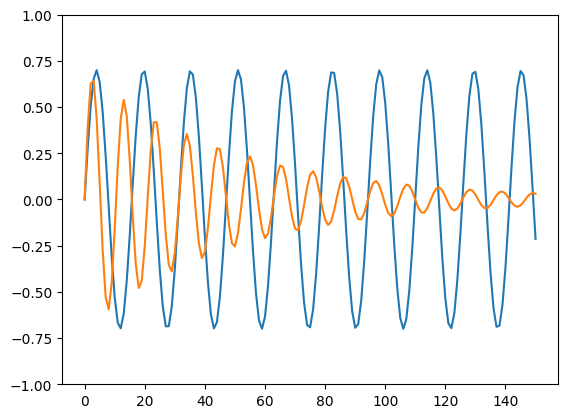

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
I_DIM = 1 # input dim
H_DIM = 10 # hidden dim
N_LAY = 4 # number of layers
E_LAY = 1 # enc_layers
E_REUL = 1 # enc_reupload
H_LAY = 1 # hid_layers
H_REUL = 1 # hid_reupload
PO_DIM = -1 # pOut_dim
A_Q_OUT = False # all_qubits_out
PRED_LEN = 1 # pred_length
# PRED_LEN = 10 # pred_length
OUT_TYP = 0 # out_type
ENWE = 2 # enc_n_weights_each
HNWE = 2 # hid_n_weights_each
EVG = None # enc_v_gate
ELVG = None # enc_lay_v_gate
HVG = None # hid_v_gate
HLVG = None # hid_lay_v_gate
G_GATE = 'u2' # gate_gate
L_GATE = 'u2' # lay_gate
N_O_LAY = None # n_out_lay
O_GATE = 'rot' # out_gate
N_HO_LAY = None # n_hout_lay
HO_GATE = 'rot' # hout_gate

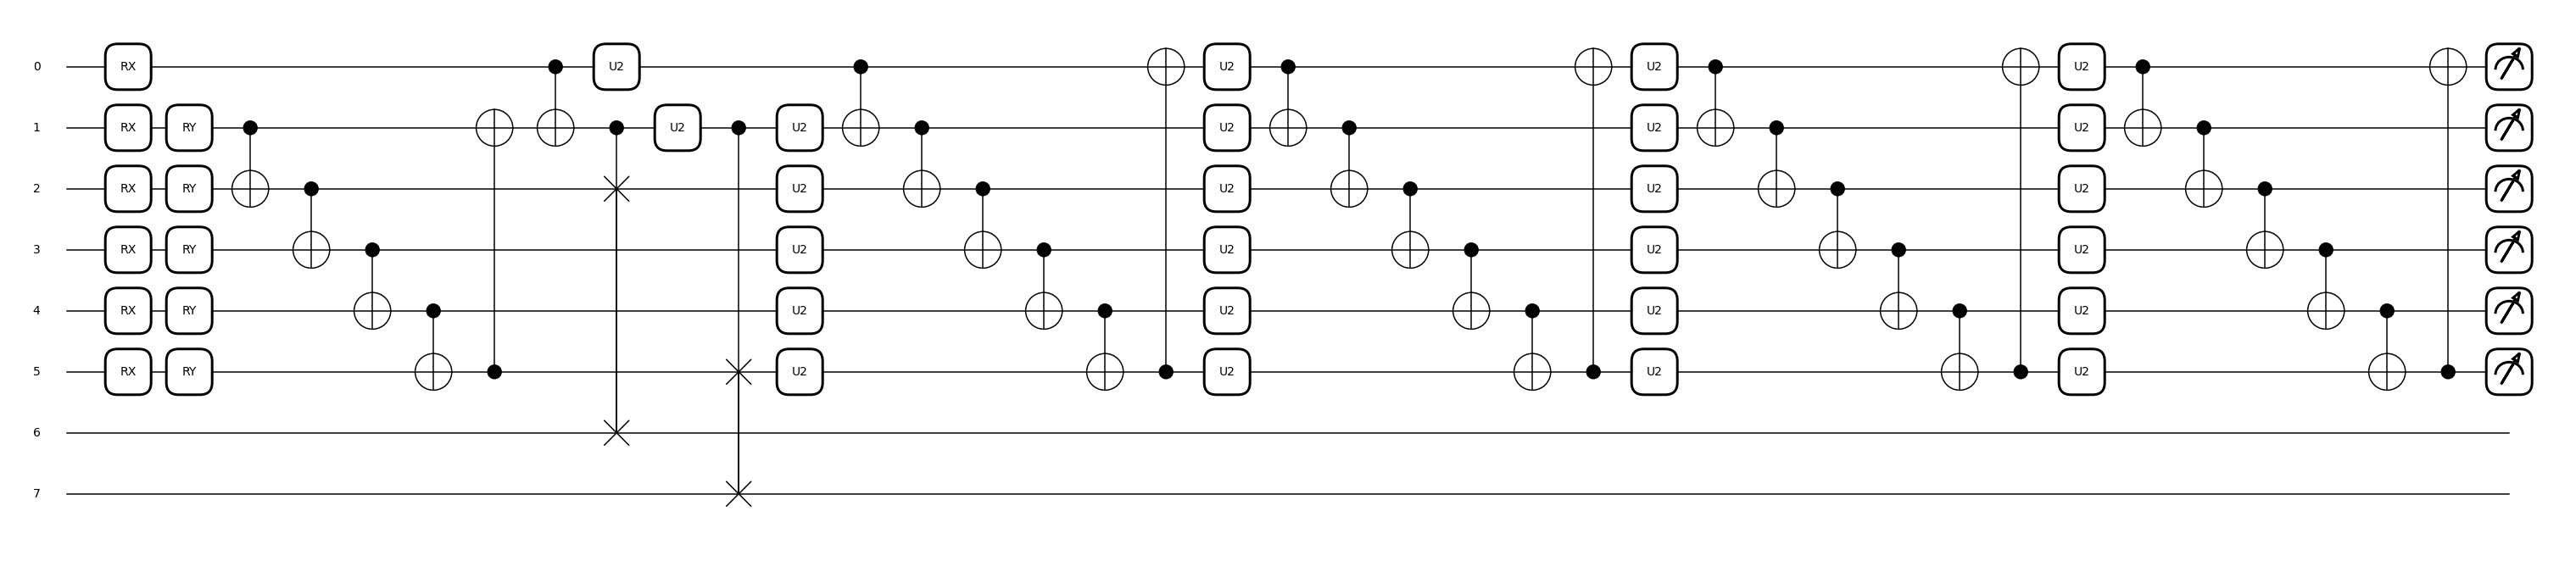

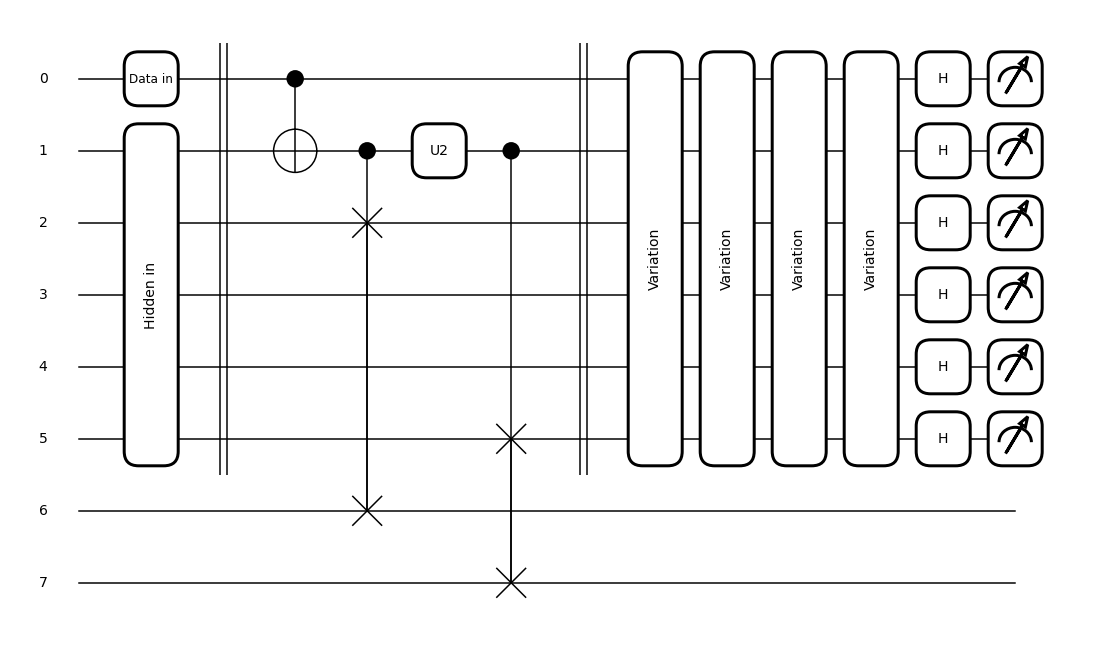

In [11]:
kk = SQGRU(I_DIM, H_DIM, N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL, hid_layers=H_LAY, hid_reupload=H_REUL,
           pOut_dim=PO_DIM, enc_n_weights_each=ENWE, hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
           hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
           n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE)
kk.draw_circuit(expansion_strategy='device')
kk.draw_circuit(measure_basis='x', probs_out=False)

In [12]:
kk.test()

Test inputs:
[[0.8182713 ]
 [0.48394728]
 [0.14487483]]
Test outputs (Ys, outs, Hs):
(Array([[ 0.07947039, -0.23174759,  0.12555142, -0.13399691,  0.14391824,
         0.13556501,  0.05314667, -0.02638995,  0.01704917,  0.03871006,
        -0.03937   ,  0.06241887],
       [ 0.07920666, -0.23188423,  0.12676658, -0.13616553,  0.14042818,
         0.13691673,  0.05281016, -0.02869119,  0.01713482,  0.038583  ,
        -0.03787214,  0.06309612],
       [ 0.07888443, -0.23174282,  0.12791028, -0.13832045,  0.13666816,
         0.13820619,  0.05249973, -0.03102644,  0.01724002,  0.03842489,
        -0.03629086,  0.06392007]], dtype=float64), Array([[ 0.07947039, -0.23174759],
       [ 0.07920666, -0.23188423],
       [ 0.07888443, -0.23174282]], dtype=float64), Array([[ 0.12555142, -0.13399691,  0.14391824,  0.13556501,  0.05314667,
        -0.02638995,  0.01704917,  0.03871006, -0.03937   ,  0.06241887],
       [ 0.12676658, -0.13616553,  0.14042818,  0.13691673,  0.05281016,
        -0.0

In [13]:
kk.num_weights

72

In [11]:
def out_fn(x):
    return x[:,0:1]

In [12]:
init_fun, qgru_rnn = stax.serial(qgru(I_DIM,H_DIM,N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL,
                                      hid_layers=H_LAY, hid_reupload=H_REUL, all_qubits_out=A_Q_OUT,
                                      pred_length=PRED_LEN, out_type=OUT_TYP, enc_n_weights_each=ENWE,
                                      hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
                                      hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
                                      n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE,
                                      out_fun=out_fn))

## Train

In [13]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### start

In [21]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            # reset
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.13655533289157532   89.40131306648254 sec       
199: 0.16899703718413556   124.79516577720642 sec       
299: 0.16864390195795012   159.00237441062927 sec      
399: 0.1524411655378513   182.44295644760132 sec       
learning rate: 0.1
499: 0.14130115742021784   201.5836250782013 sec        
599: 0.10870288289128965   220.5563747882843 sec       
699: 0.08357404512843745   240.79808497428894 sec      
799: 0.06892646142929269   259.9873037338257 sec       
899: 0.05973136554720611   279.2466003894806 sec        
999: 0.052197406938997125   298.65960001945496 sec      
1099: 0.0453718052001652   317.72621393203735 sec        
1199: 0.03800707809055116   336.75367617607117 sec       
1299: 0.03128003318207948   356.148743391037 sec         
1399: 0.027327581890253087   375.8571448326111 sec       
1499: 0.024783636134789344   395.1619095802307 sec       
1599: 0.022808192853346787   413.9667294025421 sec       
1699: 0.021040982774152554   433.19040966033936 sec

26699: 8.440046945954449e-05   5492.265662908554 sec       
26799: 8.286944775629172e-05   5504.397074222565 sec       
26899: 8.466346722896419e-05   5516.310445308685 sec       
26999: 8.724840652687803e-05   5528.244752168655 sec       
27099: 8.008992903500607e-05   5540.406083583832 sec       
27199: 7.95284393534792e-05   5552.278358459473 sec         
27299: 7.918321980437437e-05   5564.133421421051 sec       
27399: 7.927732657663061e-05   5576.407863140106 sec       
27499: 7.842459908289377e-05   5588.342341661453 sec        
27599: 9.506640783898267e-05   5600.225182533264 sec        
27699: 7.814733494874052e-05   5612.397601604462 sec       
27799: 7.729987772633863e-05   5624.377050638199 sec       
27899: 7.670985813391222e-05   5636.297619342804 sec       
27999: 7.61886133018776e-05   5648.492451429367 sec        
28099: 7.751371334197673e-05   5660.464404582977 sec       
28199: 7.627944905646284e-05   5672.564873933792 sec       
28299: 7.568463562110416e-05   5684.7

52899: 0.00015548440413098956   8637.224869012833 sec      
52999: 0.0001502782801603977   8649.280463457108 sec       
53099: 0.00014759786537847495   8661.454458713531 sec      
53199: 0.0001449483083882945   8673.745049476624 sec       
53299: 0.00013859531514297547   8685.77532339096 sec       
53399: 0.00013849430045373358   8697.756308794022 sec      
53499: 0.00013041454290885495   8709.97403383255 sec       
53599: 0.00012599950610596197   8721.984705209732 sec      
53699: 0.00012464976833718406   8733.930101394653 sec      
53799: 0.00011965094358872702   8746.085208415985 sec      
53899: 0.00012435033563435526   8758.01782798767 sec       
53999: 0.00011531929307518161   8769.983766555786 sec      
54099: 0.00011146493447666311   8782.121886253357 sec      
54199: 0.00012020229575151303   8794.105330228806 sec      
54299: 0.00011714873645973075   8806.06650185585 sec       
54399: 0.000119584019054636   8818.276586532593 sec        
learning rate: 0.0015625
54499: 0.000106

78999: 0.00018296247908879275   11773.24465417862 sec       
79099: 0.00017975368474298044   11785.132100582123 sec      
79199: 0.00017807159211018805   11797.021177768707 sec      
79299: 0.00017659579407726882   11809.217999458313 sec      
79399: 0.0001751539703248379   11821.15859079361 sec        
learning rate: 0.2
79499: 0.0020169064492406214   11833.068583250046 sec      
79599: 0.001118187743939617   11845.235865831375 sec       
79699: 0.0008639676805929659   11857.179914712906 sec      
79799: 0.0008699912967787029   11869.125582933426 sec      
79899: 0.000873981989849538   11881.307240009308 sec       
79999: 0.0020221867654214216   11893.227890014648 sec      
learning rate: 0.1
80099: 0.0012441354856120974   11905.135033369064 sec      
learning rate: 0.05
80199: 0.0005889641584534763   11917.28028345108 sec       
80299: 0.0004954439846773964   11929.158236265182 sec       
80399: 0.00047128223812698363   11941.061213493347 sec      
80499: 0.0002973932097535155   1195

104699: 0.0002528552539722761   14859.950435638428 sec       
104799: 0.0002764252690877833   14872.186358213425 sec       
104899: 0.00023741129064982363   14884.242434740067 sec      
104999: 0.0002341301785187244   14896.120906591415 sec       
105099: 0.0002544895500393076   14908.257752656937 sec       
105199: 0.00024176700871870828   14920.668540477753 sec      
105299: 0.0002658115692715984   14932.606389522552 sec       
learning rate: 0.00625
105399: 0.00022446220209735348   14944.90511250496 sec       
105499: 0.000220431267540519   14956.930532217026 sec        
105599: 0.0002171106187121589   14968.854837417603 sec       
105699: 0.00021346316880794028   14980.817562580109 sec      
105799: 0.0002093440457273857   14993.046379804611 sec       
105899: 0.00020461381319302475   15004.958866119385 sec      
105999: 0.0002448903222015675   15016.821865081787 sec       
106099: 0.00020082949828729188   15028.951253175735 sec      
106199: 0.00019500670437239796   15040.86597418

...

206699: 9.294111007481393e-05   27153.092037200928 sec       
206799: 9.22158325662491e-05   27165.34507393837 sec         
206899: 9.853599158052425e-05   27177.379771232605 sec       
206999: 8.847619398586728e-05   27189.331054210663 sec       
207099: 9.562748736689398e-05   27201.56555581093 sec        
207199: 8.92353034189835e-05   27213.606776237488 sec        
207299: 8.841099315295887e-05   27225.561909675598 sec       
207399: 8.38556434050318e-05   27237.457768678665 sec        
207499: 8.690792104161986e-05   27249.77564716339 sec        
207599: 8.324133703490247e-05   27261.910042762756 sec       
207699: 7.950312928722611e-05   27273.97195148468 sec        
207799: 8.053622542024699e-05   27286.26128911972 sec        
207899: 8.092744534273779e-05   27298.39949941635 sec        
207999: 8.000235924928634e-05   27310.42787861824 sec        
learning rate: 0.00625
208099: 7.816968980855056e-05   27322.541214466095 sec       
208199: 7.625963993229307e-05   27334.817878723

232199: 0.010671830443834502   30237.850479364395 sec       
232299: 0.004135319039940464   30250.44701886177 sec        
232399: 0.002462548959193306   30262.618380069733 sec       
232499: 0.019448797060219306   30274.593310832977 sec       
232599: 0.06243297000253964   30286.645748376846 sec       
232699: 0.009205462191899319   30298.890978336334 sec      
learning rate: 0.1
232799: 0.0012183463505700772   30310.934435606003 sec      
232899: 0.0009752501694462213   30322.88279080391 sec       
232999: 0.0016252170188378514   30335.13754415512 sec       
233099: 0.0008124958881454783   30347.131159305573 sec      
233199: 0.00043605882505438746   30359.163697957993 sec      
233299: 0.0004614537870703056   30371.36203455925 sec        
233399: 0.0004605538689732585   30383.402667284012 sec       
233499: 0.0003844330530204427   30395.4055685997 sec         
233599: 0.0019812226863632552   30407.44306731224 sec        
233699: 0.00029136359635248903   30419.689477443695 sec      
2

257599: 0.0004990282145564417   33312.12703561783 sec        
257699: 0.0004997062363589123   33324.090250492096 sec       
257799: 0.0002764321621882147   33336.374809741974 sec       
learning rate: 0.025
257899: 0.00027585432078424554   33348.49916267395 sec       
257999: 0.000247799797118991   33360.70686793327 sec         
258099: 0.00022961107772814045   33372.77237224579 sec       
258199: 0.00028391626408096483   33385.05294942856 sec       
258299: 0.0011486311079876121   33397.02024412155 sec        
258399: 0.0002559682589884836   33409.014974832535 sec       
learning rate: 0.0125
258499: 0.00021799766230402393   33421.32223653793 sec       
258599: 0.00022002308102111225   33433.3057744503 sec        
258699: 0.00020615370804459872   33445.25439167023 sec       
258799: 0.00020304274901533073   33457.28778219223 sec       
258899: 0.00020131850816312153   33469.57070469856 sec       
258999: 0.00020472044234516107   33481.60202169418 sec       
259099: 0.00055765327869675

282999: 6.419906711436833e-05   36384.29775047302 sec       
283099: 6.36222248451688e-05   36396.2745923996 sec         
283199: 6.310558706872335e-05   36408.23277783394 sec       
283299: 6.258696704630108e-05   36420.48751664162 sec       
learning rate: 0.2
283399: 0.0077411381479749195   36432.63930988312 sec      
283499: 0.018395678318525236   36444.66125202179 sec        
283599: 0.007276899267211806   36456.73202729225 sec        
283699: 0.0015414892612184122   36469.07583427429 sec       
283799: 0.003310618576579851   36481.11938261986 sec        
283899: 0.00744138361479147   36493.15228152275 sec         
283999: 0.001773569256232241   36505.35171341896 sec        
learning rate: 0.1
284099: 0.0009568565776583222   36517.37175941467 sec       
284199: 0.0004913799052455959   36529.416459321976 sec      
284299: 0.00032511614241795966   36541.34359502792 sec       
284399: 0.00033020173985457985   36553.76527237892 sec       
284499: 0.00028169018591549884   36565.7470815

308499: 0.0008414727210659187   39470.175941705704 sec      
learning rate: 0.0001953125
308599: 0.00022883282720575525   39482.402156353 sec         
308699: 0.00022838117662777016   39494.3216073513 sec        
308799: 0.0002285281929363715   39506.191883563995 sec       
308899: 0.0002277530108393336   39518.08394408226 sec        
308999: 0.00022796891114707548   39530.27423429489 sec       
309099: 0.0002270353993843292   39542.23368692398 sec        
309199: 0.0002268400544400259   39554.17921042442 sec        
309299: 0.0002264925111115027   39566.49159526825 sec        
learning rate: 0.2
309399: 0.004627226977534242   39578.617837667465 sec      
309499: 0.0011499811522242872   39590.67713665962 sec       
309599: 0.0014745606298342628   39602.67104387283 sec       
309699: 0.0008120926418412949   39614.86760473251 sec       
309799: 0.002495245909542629   39626.83628177643 sec        
309899: 0.0005880230821058647   39638.77304172516 sec       
309999: 0.0006859299363762732  

In [22]:
minLoss

Array(6.03423464e-05, dtype=float64)

In [23]:
# Save
# lossList, minLoss, params, best_params, loc_params_list, reset_steps
# jnp.save(nb_name+'_state', (lossList, minLoss, params, best_params, loc_params_list, reset_steps))

with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

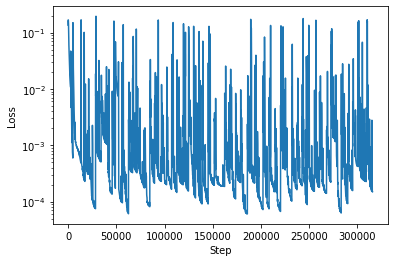

In [24]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

In [18]:
# predict next 50 steps
pre_next_1 = 50
_, qgru_rnn2 = stax.serial(qgru(I_DIM,H_DIM,N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL,
                                hid_layers=H_LAY, hid_reupload=H_REUL, all_qubits_out=A_Q_OUT,
                                pred_length=pre_next_1, out_type=OUT_TYP, enc_n_weights_each=ENWE,
                                hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
                                hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
                                n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE,
                                out_fun=out_fn))

# # predict next 110 steps
# pre_next_2 = pre_next_1 + 50
# _, qgru_rnn3 = stax.serial(qgru(I_DIM,H_DIM,N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL,
#                                 hid_layers=H_LAY, hid_reupload=H_REUL, all_qubits_out=A_Q_OUT,
#                                 # pred_length=50, out_type=OUT_TYP, enc_n_weights_each=ENWE,
#                                 pred_length=pre_next_2, out_type=OUT_TYP, enc_n_weights_each=ENWE,
#                                 hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
#                                 hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
#                                 n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE,
#                                 out_fun=out_fn))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

# @jax.jit
# def jit_rnn_2(params, inputs):
#     return qgru_rnn3(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

### best parameters

In [28]:
ys = jit_rnn(best_params, xs)

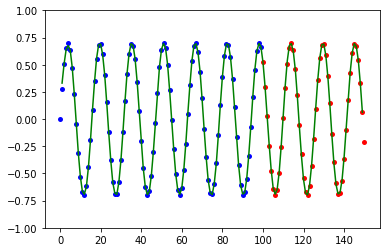

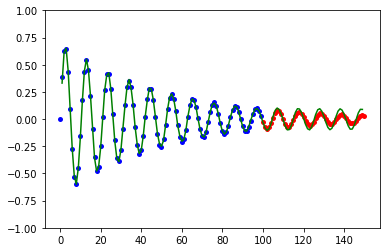

In [29]:
for idx in [0,1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [30]:
ys = jit_rnn(params, xs)

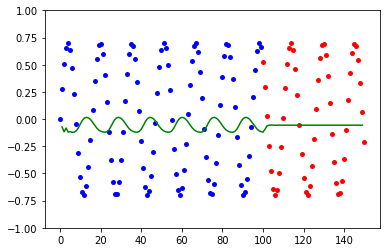

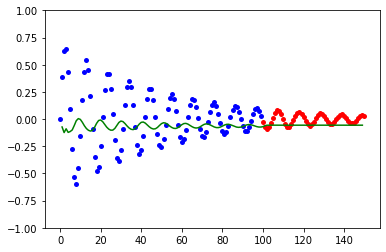

In [31]:
for idx in [0,1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [21]:
# load
# lossList, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [22]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    ys = jit_rnn(i_params, xs)
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[283300,
 Array(6.2586967e-05, dtype=float64),
 Array(8.24903199e-05, dtype=float64),
 [Array([ 2.10457581,  3.57504019,  8.46497831,  4.03139867,  4.78603519,
          1.70486926,  9.48161085,  5.4343636 ,  1.77509359,  6.11353738,
          2.99617463,  2.97229302,  2.72822029,  3.16972182,  5.85653991,
          3.10629874,  6.76774307,  2.65427141,  6.43479548,  6.60153506,
          3.25223849,  3.3721197 ,  2.58903977,  5.92591154,  0.59878505,
          4.73833272,  4.18351331,  5.54726772,  5.61733492,  8.11414802,
          1.18629374,  2.31505528,  5.55307993,  3.96892968,  1.55241323,
          1.57271053,  3.91200432,  1.8601431 ,  6.97896544,  4.78808305,
          3.96075843,  0.02232422,  7.86783242,  6.85474984,  2.91654675,
          6.33431075,  3.12839804,  4.8236237 ,  0.76697377,  7.04954691,
          4.49362948,  1.88791887,  4.56949665,  5.87265523,  4.19311489,
         -0.3939838 ,  4.45697036,  1.80468433,  2.16892607,  0.15120774,
          6.43091726,  1.6

In [26]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

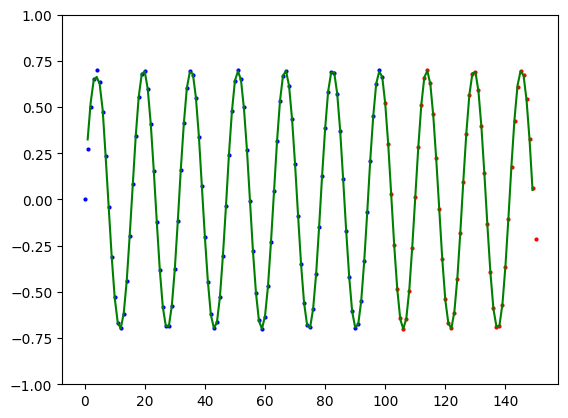

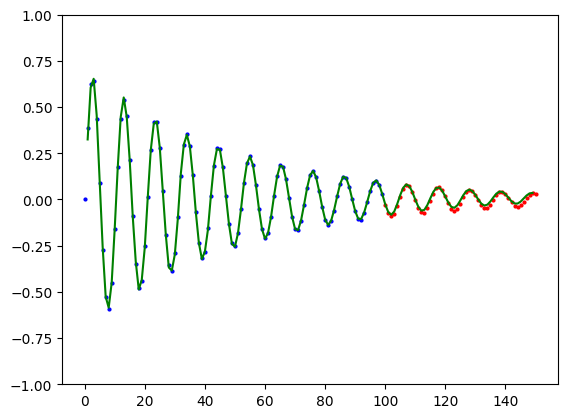

In [23]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

In [36]:
import csv
with open(nb_name+'_example.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['True 1', 'True 2', 'Prediction', '', 'True 1', 'True 2', 'Prediction'])
    writer.writerow([true1[0][0], '', '', '', true1[1][0], '', ''])
    i = 0
    for _ in true1[:,1:].T:
        writer.writerow([_[0], '', min_ys[0][i][0], '', _[1], '', min_ys[1][i][0]])
        i += 1
    for _ in true2.T:
        writer.writerow(['', _[0], min_ys[0][i][0], '', '', _[1], min_ys[1][i][0]])
        i += 1

best: [283300, Array(6.2586967e-05, dtype=float64), Array(8.24903199e-05, dtype=float64)]
17500 0.00022800374027686016 0.008365765980290377


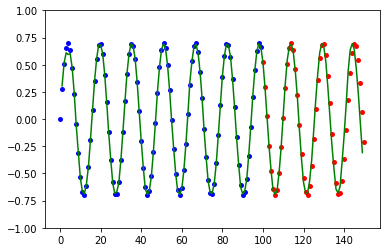

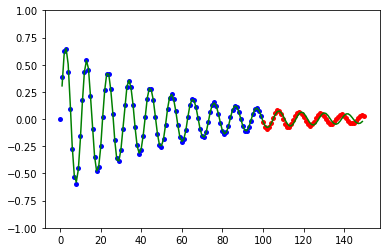

21200 0.0003046870352417156 0.0015708730347767691


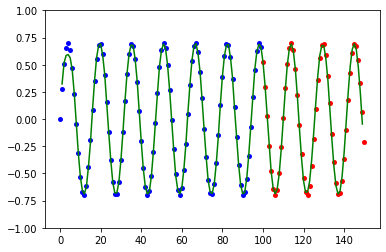

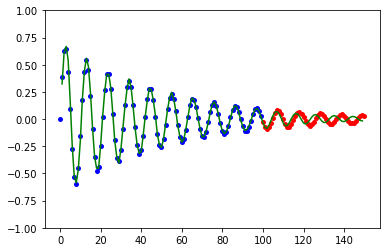

28500 7.472718334652665e-05 0.0005953029758557657


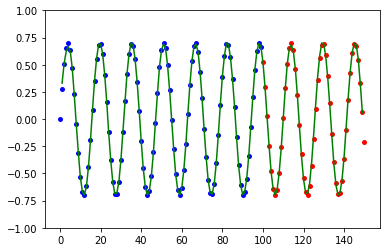

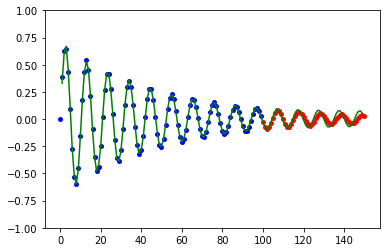

34200 0.0005060537578262486 0.0008047503259510947


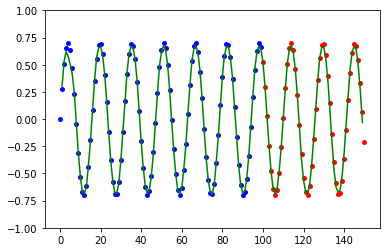

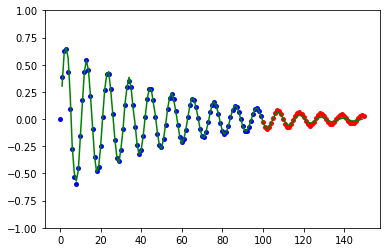

40500 0.0010333465105814932 0.1325125286914172


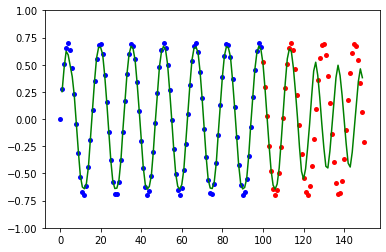

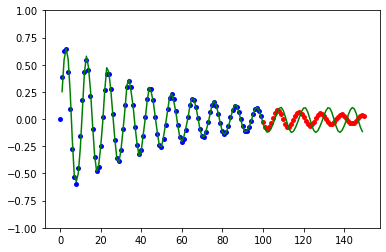

45800 0.00013570874661524257 0.0012060578407879189


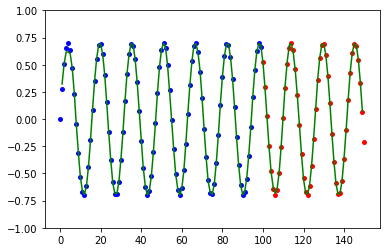

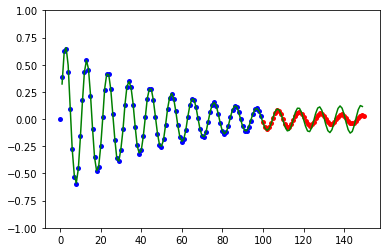

56400 9.521206168514211e-05 0.0008114365148932916


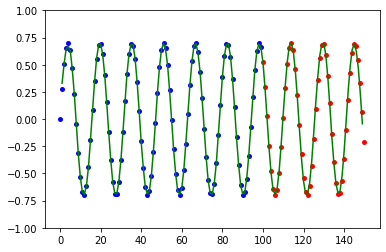

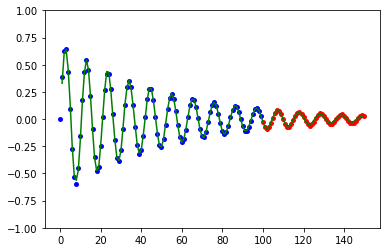

62700 6.07525194158008e-05 0.0005851144730337461


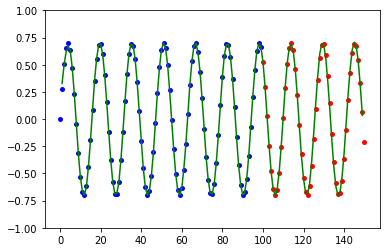

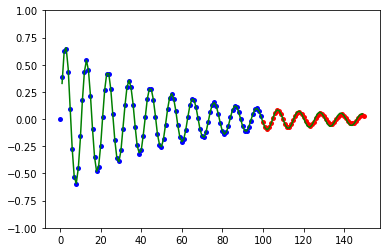

66900 0.00032586328833528633 0.0011316592794811703


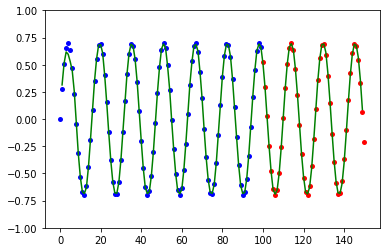

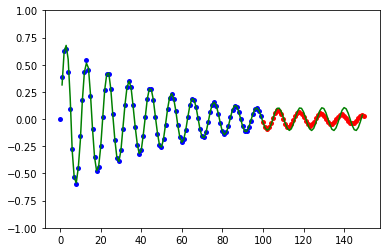

71400 0.00032402203520921525 0.003127762985782239


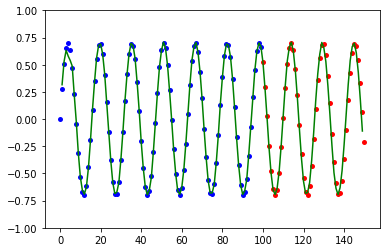

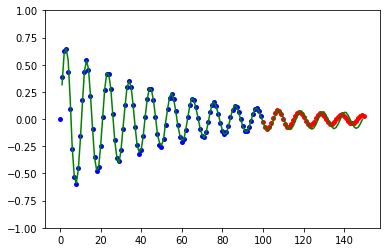

79400 0.0001751539703248379 0.0010043835737181383


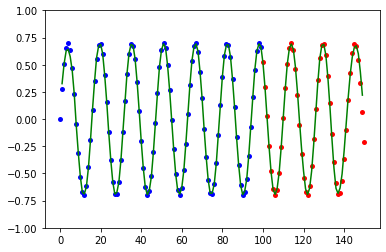

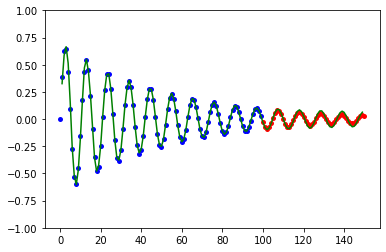

84800 8.108044635989053e-05 0.025734384186604436


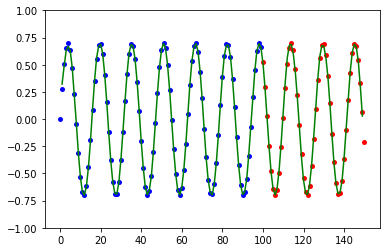

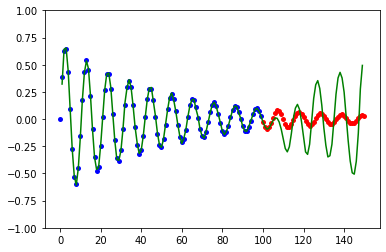

89700 0.00021107279805013132 0.0006942491380083726


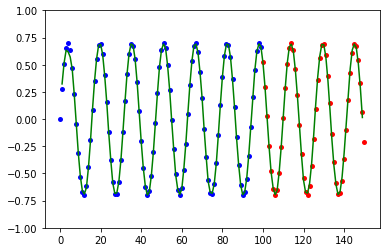

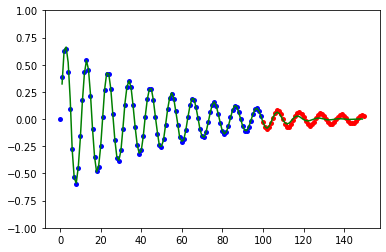

96800 0.00022830411646210255 0.0021045363956095904


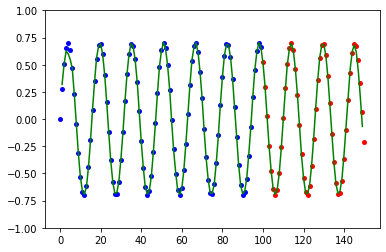

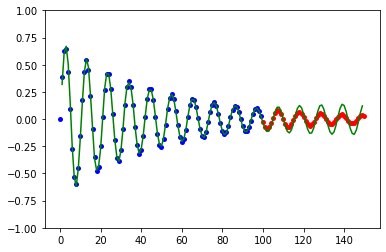

102200 0.00019942758015659005 0.003634488006788685


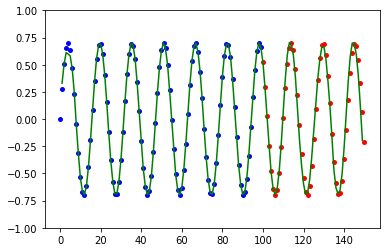

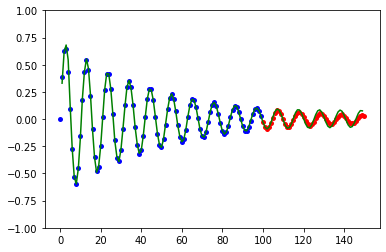

107400 0.00016502517284552445 0.08826993542879759


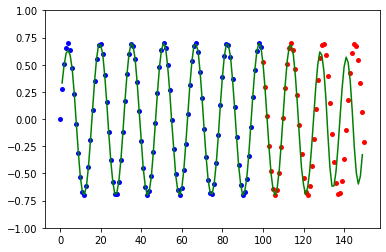

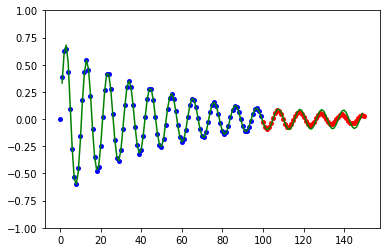

112800 0.0001450185448305236 0.008865389101266642


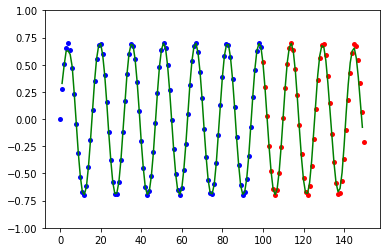

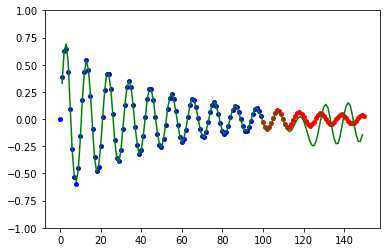

119300 0.00019873660330354073 0.0006523766470144476


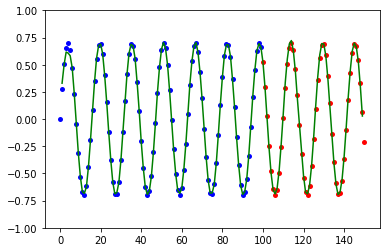

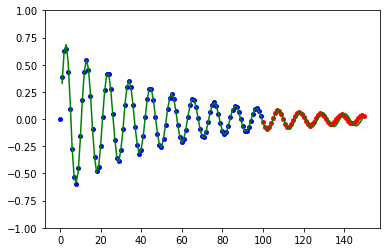

124900 0.00015422404351056763 0.07078481395685293


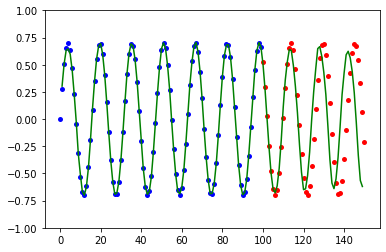

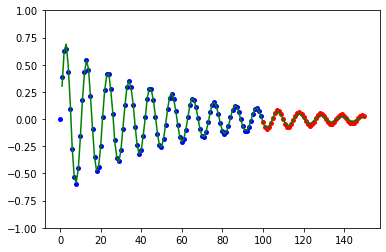

132200 0.00011598822518404065 0.0016218923083030406


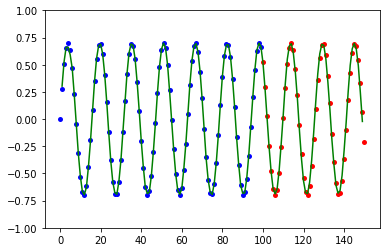

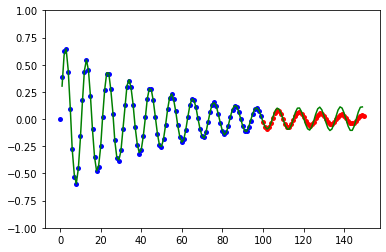

138900 9.08119706680687e-05 0.0019307899565636358


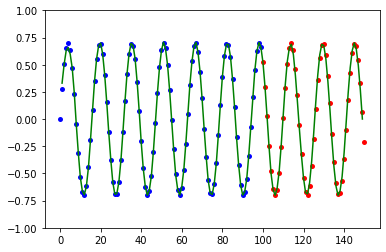

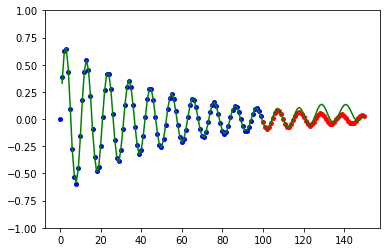

145300 9.077477385741455e-05 0.0007617195812172005


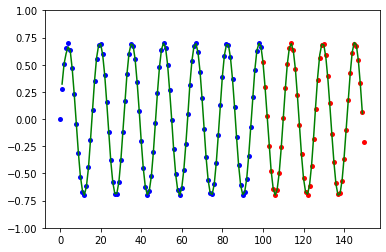

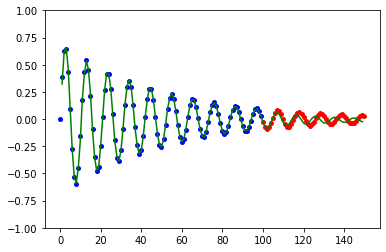

151700 0.00019604077823876252 0.1994457813239623


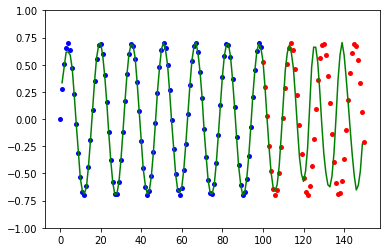

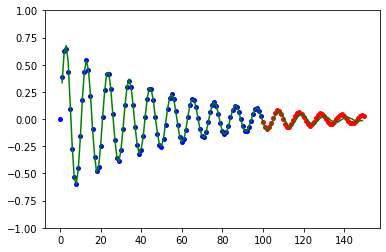

162400 0.0001857684036859647 0.06628083113593786


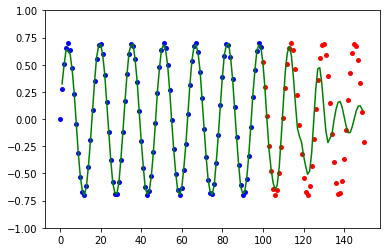

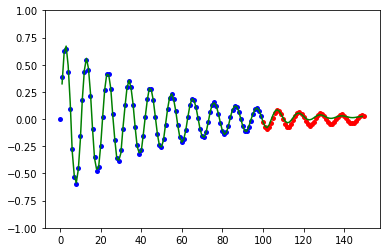

167800 0.00021126169195793712 0.0008333161275514805


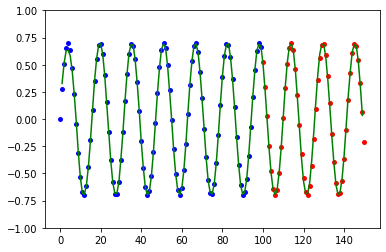

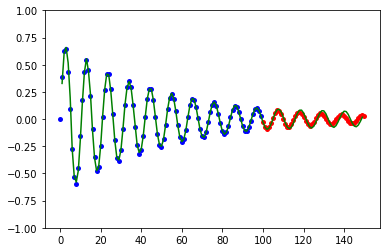

173800 0.00011150490116001749 0.009238651188573034


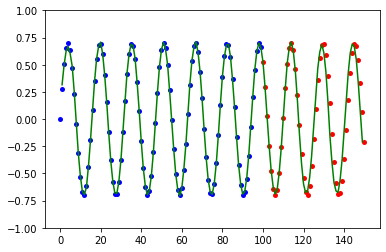

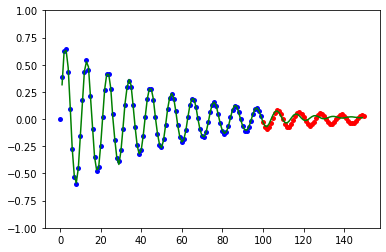

179000 0.00021808971766233213 0.0005716475652003696


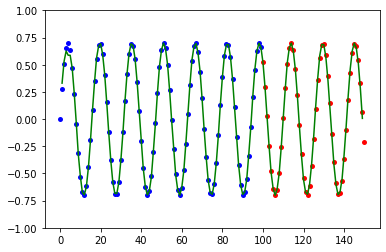

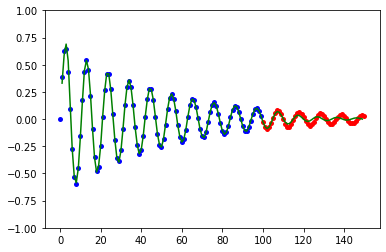

186000 6.0342346369565346e-05 0.000622280222360942


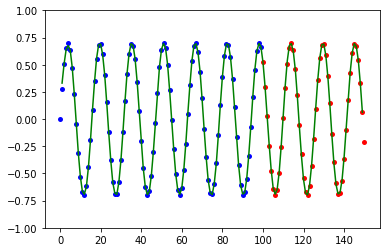

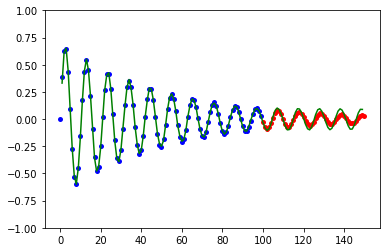

188800 0.0003201914121965807 0.0005177172604212209


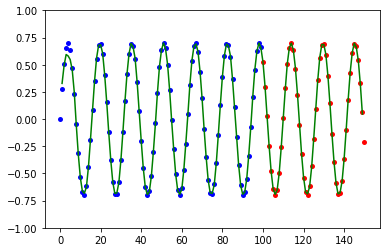

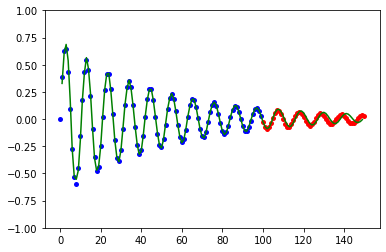

193500 0.00021305274769608368 0.012170585724719327


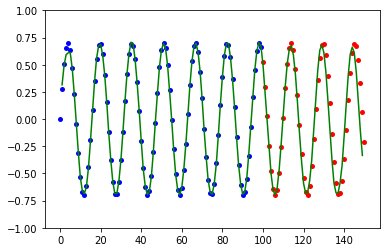

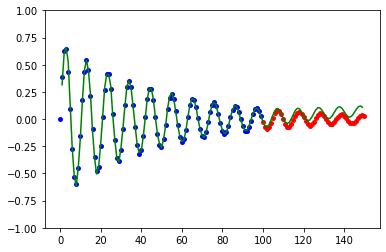

202200 7.195738767321016e-05 0.0005179523929006101


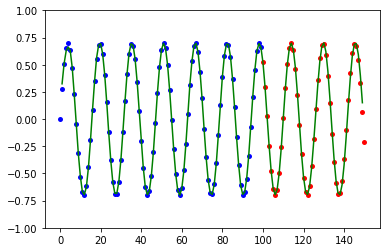

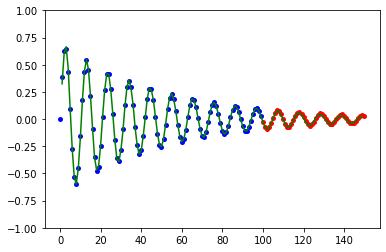

208500 7.431561294217123e-05 0.002214427937865061


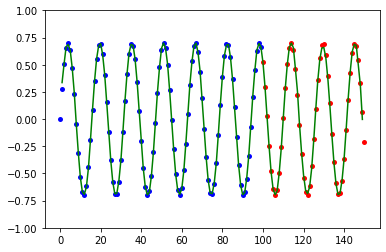

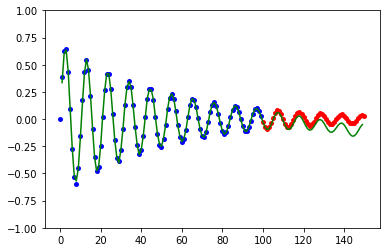

214800 0.00014912334469864387 0.0002909790519802383


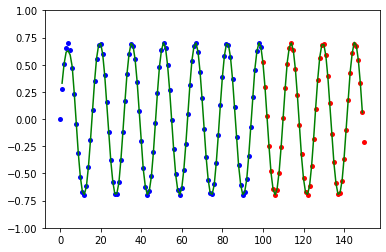

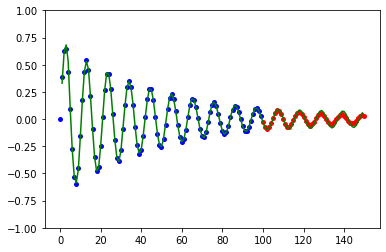

220400 6.672265934417716e-05 0.009478169995453126


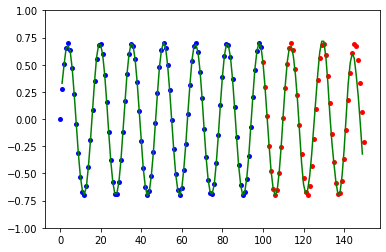

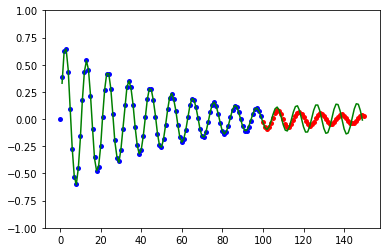

225300 0.00036508609423765645 0.0007984047212210507


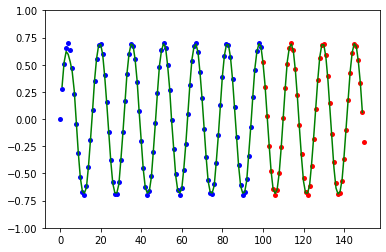

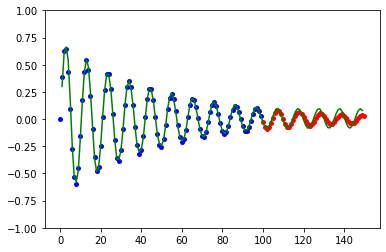

232100 0.00010159851485940446 0.004809671636271064


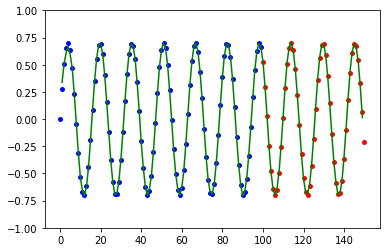

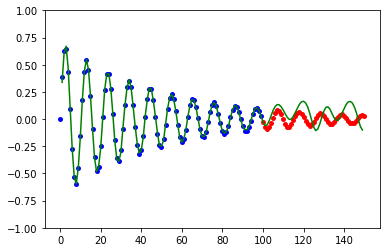

237400 0.00016226837266554672 0.003858104116082148


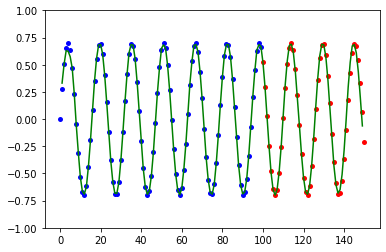

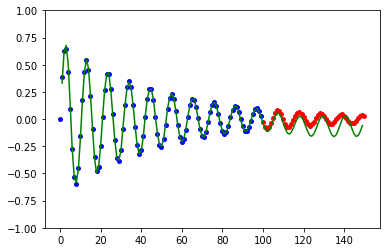

242700 0.00019059080784335049 0.023752628830735395


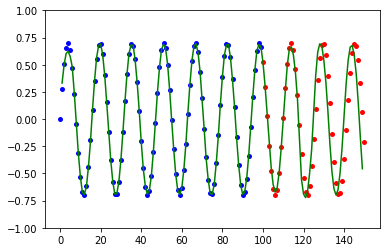

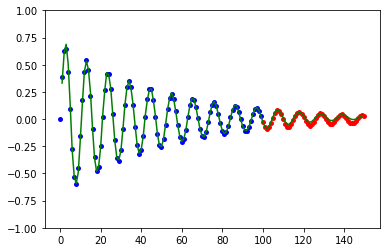

248100 8.840262500350289e-05 0.0001808739633664684


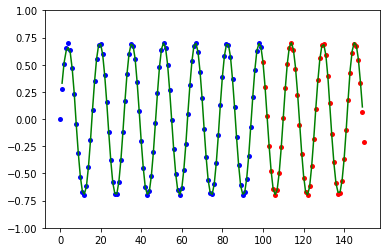

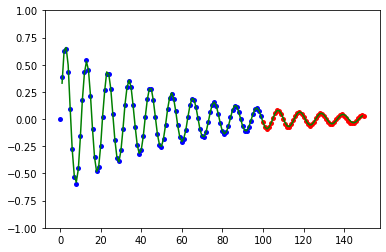

255500 0.000152411414423706 0.07106794878099666


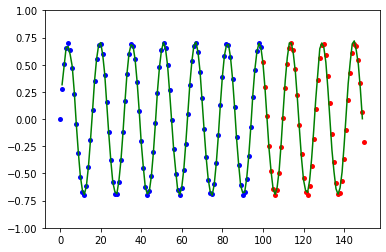

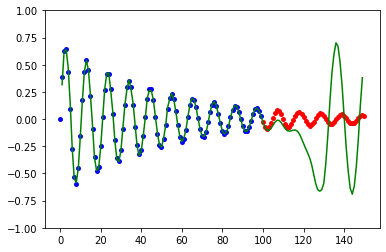

260800 0.0001797650879414808 0.0019401844188316336


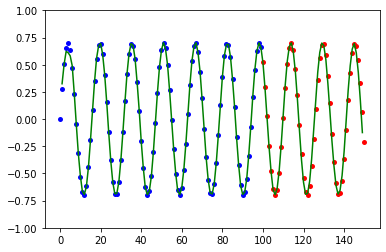

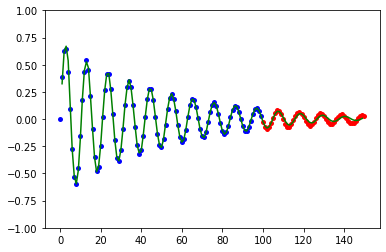

268100 0.00014002907843416445 0.0009091274707106301


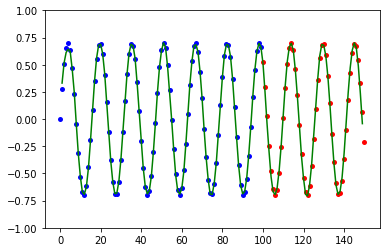

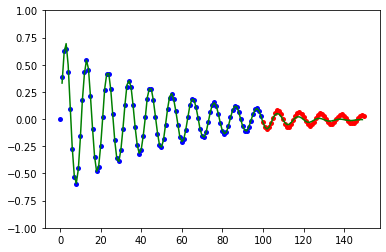

272600 0.00021993782723985788 0.0009298581412708311


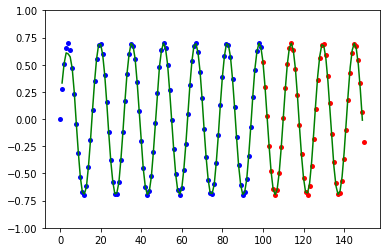

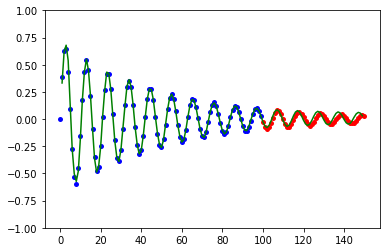

277200 0.0011609491046651477 0.1508111376777683


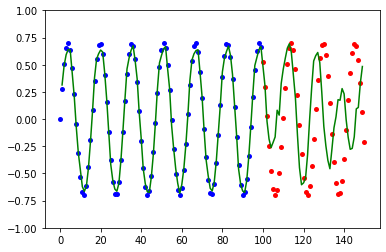

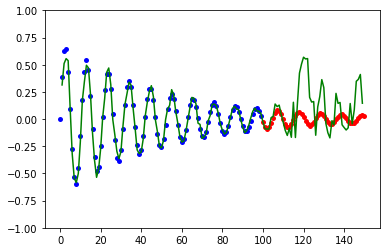

283300 6.258696704630108e-05 8.249031985656137e-05


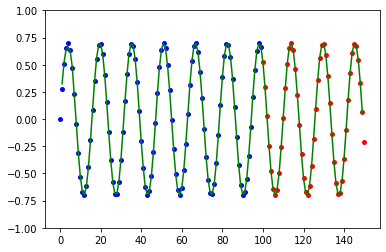

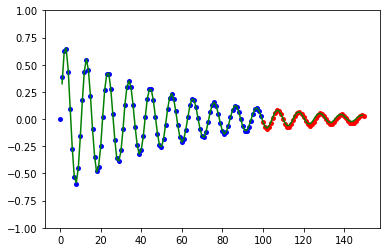

290100 9.181870906654098e-05 0.0005274097031445278


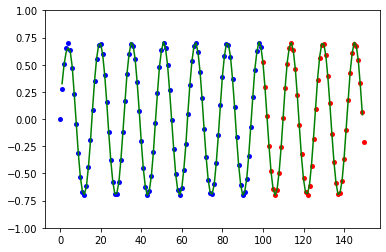

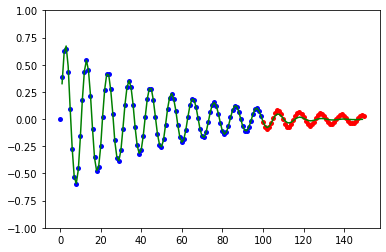

295200 0.00015655330555124138 0.00622903410725819


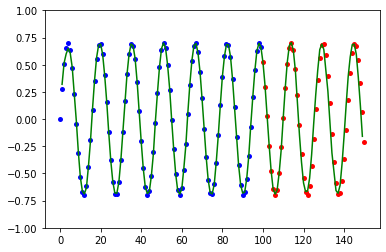

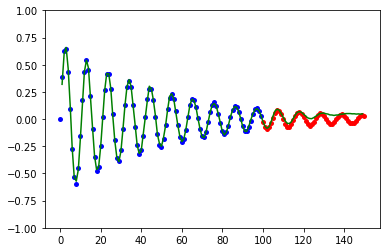

300100 0.00042119690756622664 0.0005992940668116323


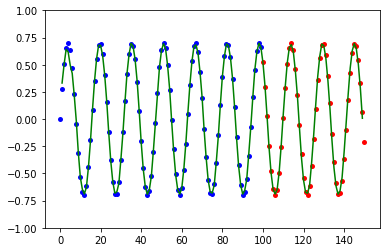

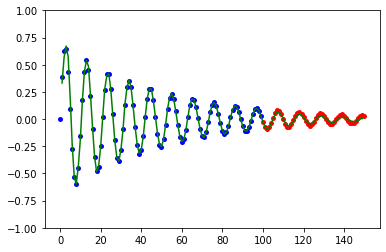

309300 0.0002264925111115027 0.002696701258180893


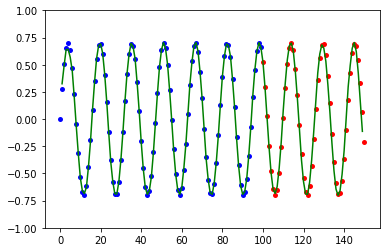

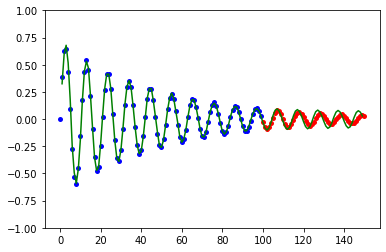

315800 0.00014895338663466394 0.04391537594482307


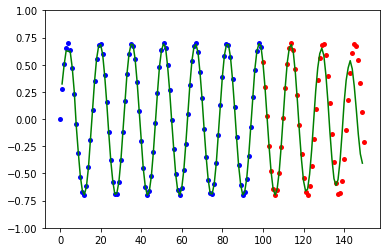

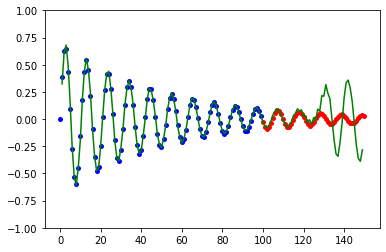

In [35]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [36]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.01944122, dtype=float64)

In [37]:
len(test_result)

50